# Convolutional Neural Networks vs. Multi-Layer Perceptrons

In the previous notebook (`01_mlp_mnist`) we trained a **Multi-Layer Perceptron (MLP)** to classify handwritten digits and reached about 97–98% accuracy. In this notebook we introduce a fundamentally different architecture — the **Convolutional Neural Network (CNN)** — and compare the two head-to-head.

The key question: *why would a CNN do better, and what does it cost?*

By the end of this notebook you will have:
- Understood *why* convolution is the natural operation for images (through a physics analogy)
- Built a flexible CNN and visualised its architecture
- Visualised convolutional filters **before and after** training
- Inspected the internal **feature maps** the CNN constructs from a real image
- Compared MLP and CNN performance as a function of training set size
- Explored how CNN depth and width affect performance
- Done a direct head-to-head comparison of the two architectures

## 1. Imports and Setup

In [1]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import random
import time

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.2.2


## 2. Load MNIST

Identical pre-processing to the MLP notebook — normalised to zero mean, unit standard deviation.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)

print(f"Training images : {len(train_dataset):,}")
print(f"Test images     : {len(test_dataset):,}")

Training images : 60,000
Test images     : 10,000


## 3. Why a CNN? The Physics Intuition

The MLP's first step is to **flatten** the 28×28 image into a vector of 784 numbers. This erases all spatial structure — pixel (3, 5) has no special relationship to pixel (4, 5) once they are just two entries in a long list. The network therefore has to learn, from scratch and separately for every possible position, that a horizontal stroke at the top of the image and the same stroke at the bottom are both consistent with a "7".

This is wasteful. Handwritten digits are built from the same local features — strokes, curves, loops — wherever they appear in the image. A CNN exploits this by using **convolution** instead of matrix multiplication.

### Convolution and the matched-filter analogy

Convolution is already a familiar tool in physics and signal processing. When a telescope images a point source, every photon in the focal plane is smeared by the same **point-spread function (PSF)** regardless of where in the field of view the source sits. The PSF is a **spatially invariant kernel**: the same operation repeated at every position.

A convolutional layer works exactly the same way:
- It learns a small kernel (e.g. 3×3 pixels) — analogous to a matched filter template.
- It slides this kernel over every position of the image and computes the dot product at each location — the same operation as cross-correlation.
- The result is a **feature map**: a spatial map of where in the image the template was found.

### The two key advantages

| Property | MLP | CNN |
|---|---|---|
| **Weight sharing** | Every pixel has its own weight in every neuron | One kernel is reused at every spatial position |
| **Local connectivity** | Every neuron sees all 784 pixels | Every neuron sees only a small neighbourhood (e.g. 3×3) |

Weight sharing means far fewer parameters for the same representational power. Local connectivity means the network automatically learns *local* features first, then combines them hierarchically — strokes → digits, analogous to how astronomers go from pixels to sources to structures.

## 4. Architecture Diagrams

### 4a. ASCII diagram

Here is the default CNN architecture we will use, showing how the tensor shape changes at each step:

```
Input           Conv2d+ReLU      MaxPool2d      Conv2d+ReLU      MaxPool2d       Flatten        Linear+ReLU     Linear
1×28×28    →   16×28×28    →   16×14×14   →   32×14×14    →   32×7×7     →    1568       →      128       →    10
               (1→16, 3×3)    (stride 2)      (16→32, 3×3)   (stride 2)
               ~160 params                    ~4640 params                               ~200k params    ~1.3k params
```

Compare with the MLP default:

```
Input       Linear+ReLU    Linear+ReLU     Linear
784     →      128      →      64       →    10
           ~100k params    ~8.3k params   ~650 params
```

The CNN's convolutional layers use only ~5k parameters to process the entire image; the bulk of the CNN's parameters live in the fully-connected head — exactly as in the MLP. The difference is that the CNN **compresses and organises** the 784 raw pixels into 1568 meaningful features before the FC layer sees them.

### 4b. Matplotlib architecture diagram

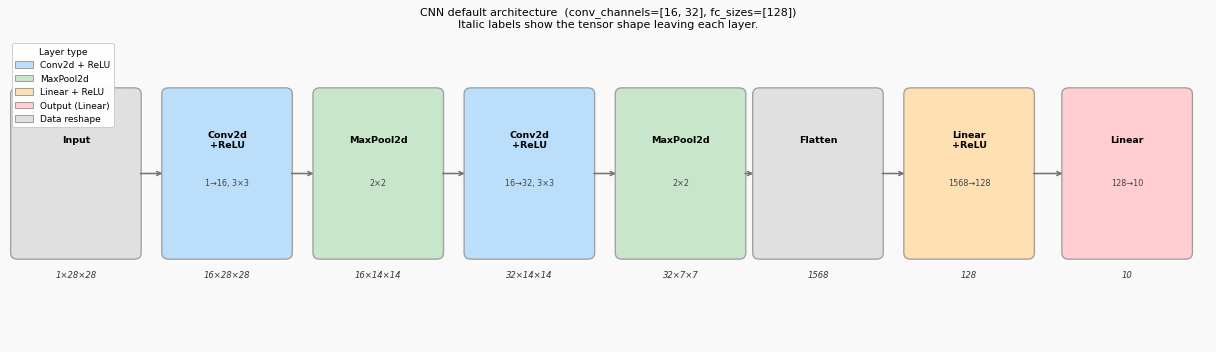

In [3]:
def draw_cnn_architecture():
    """
    Draw the default CNN architecture as a colour-coded flow diagram.
    Each box shows the layer type and the tensor shape that leaves it.
    """
    fig, ax = plt.subplots(figsize=(17, 5))
    ax.set_xlim(0, 17.5)
    ax.set_ylim(0, 5)
    ax.axis('off')
    fig.patch.set_facecolor('#f9f9f9')
    ax.set_facecolor('#f9f9f9')

    # Each entry: (main label, sub-label, output shape, x-centre, fill colour)
    layers = [
        ("Input",          "",              "1×28×28",   1.0,  '#e0e0e0'),
        ("Conv2d\n+ReLU",  "1→16, 3×3",   "16×28×28",  3.2,  '#bbdefb'),
        ("MaxPool2d",      "2×2",           "16×14×14",  5.4,  '#c8e6c9'),
        ("Conv2d\n+ReLU",  "16→32, 3×3",  "32×14×14",  7.6,  '#bbdefb'),
        ("MaxPool2d",      "2×2",           "32×7×7",    9.8,  '#c8e6c9'),
        ("Flatten",        "",              "1568",      11.8,  '#e0e0e0'),
        ("Linear\n+ReLU",  "1568→128",     "128",       14.0,  '#ffe0b2'),
        ("Linear",         "128→10",        "10",        16.3,  '#ffcdd2'),
    ]

    box_w = 1.7   # box half-width is box_w / 2
    box_h = 2.6
    y_c   = 2.8   # vertical centre of every box

    for i, (label, sublabel, shape, x, color) in enumerate(layers):
        rect = mpatches.FancyBboxPatch(
            (x - box_w / 2, y_c - box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.1",
            facecolor=color, edgecolor='#9e9e9e', linewidth=1.3, zorder=2
        )
        ax.add_patch(rect)

        # Main label (bold, e.g. "Conv2d\n+ReLU")
        ax.text(x, y_c + 0.55, label, ha='center', va='center',
                fontsize=9.5, fontweight='bold', zorder=3)

        # Sub-label (e.g. kernel size, channels)
        if sublabel:
            ax.text(x, y_c - 0.15, sublabel, ha='center', va='center',
                    fontsize=8, color='#444444', zorder=3)

        # Output-shape label below the box
        ax.text(x, y_c - box_h / 2 - 0.28, shape,
                ha='center', va='top', fontsize=8.5,
                color='#333333', style='italic', zorder=3)

        # Arrow connecting to the next layer
        if i < len(layers) - 1:
            next_x = layers[i + 1][3]
            ax.annotate(
                '', xy=(next_x - box_w / 2 - 0.06, y_c),
                xytext=(x + box_w / 2 + 0.06, y_c),
                arrowprops=dict(arrowstyle='->', color='#757575', lw=1.6),
                zorder=2
            )

    # --- Legend ---
    legend_items = [
        mpatches.Patch(facecolor='#bbdefb', edgecolor='#9e9e9e', label='Conv2d + ReLU'),
        mpatches.Patch(facecolor='#c8e6c9', edgecolor='#9e9e9e', label='MaxPool2d'),
        mpatches.Patch(facecolor='#ffe0b2', edgecolor='#9e9e9e', label='Linear + ReLU'),
        mpatches.Patch(facecolor='#ffcdd2', edgecolor='#9e9e9e', label='Output (Linear)'),
        mpatches.Patch(facecolor='#e0e0e0', edgecolor='#9e9e9e', label='Data reshape'),
    ]
    ax.legend(handles=legend_items, loc='upper left', fontsize=9,
              framealpha=0.95, edgecolor='#cccccc', title='Layer type', title_fontsize=9)

    ax.set_title(
        "CNN default architecture  (conv_channels=[16, 32], fc_sizes=[128])\n"
        "Italic labels show the tensor shape leaving each layer.",
        fontsize=11, pad=12
    )
    plt.tight_layout()
    plt.show()


draw_cnn_architecture()

## 5. Define the CNN

The class below mirrors the flexible design of the MLP: `conv_channels` controls how many filters each convolutional layer learns, and `fc_sizes` controls the fully-connected head.

A few new PyTorch building blocks:
- **`nn.Conv2d(in_ch, out_ch, kernel_size, padding)`** — applies `out_ch` different 2D kernels to the input. `padding=1` with a 3×3 kernel preserves the spatial dimensions (the output has the same height and width as the input).
- **`nn.MaxPool2d(2, 2)`** — slides a 2×2 window and keeps the maximum value in each window. This halves both spatial dimensions. Pooling provides a degree of translation invariance: a feature that shifts by one pixel still produces the same pooled output.

In [4]:
class CNN(nn.Module):
    """
    A flexible CNN for MNIST classification.

    Parameters
    ----------
    conv_channels : list of int
        Number of filters in each convolutional layer.
        E.g. [16, 32] creates two conv layers.
    fc_sizes : list of int
        Widths of the fully-connected hidden layers before the output.
    """
    def __init__(self, conv_channels=[16, 32], fc_sizes=[128]):
        super(CNN, self).__init__()

        # --- Convolutional backbone ---
        conv_layers = []
        in_ch = 1  # MNIST images have 1 colour channel (greyscale)
        for out_ch in conv_channels:
            # Conv2d + ReLU + MaxPool is the standard "convolutional block".
            # padding=1 keeps spatial size the same after the 3×3 convolution;
            # MaxPool2d(2,2) then halves it.
            conv_layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            in_ch = out_ch

        self.conv_net = nn.Sequential(*conv_layers)

        # --- Compute the flattened size after all pooling layers ---
        # Each MaxPool2d(2,2) halves both H and W, so n_pools halvings give:
        n_pools = len(conv_channels)
        spatial = 28 // (2 ** n_pools)   # e.g. 28 // 4 = 7 for two pool layers
        flat_size = conv_channels[-1] * spatial * spatial

        # --- Fully-connected head ---
        fc_layers = []
        in_feat = flat_size
        for out_feat in fc_sizes:
            fc_layers.append(nn.Linear(in_feat, out_feat))
            fc_layers.append(nn.ReLU())
            in_feat = out_feat
        fc_layers.append(nn.Linear(in_feat, 10))  # 10 digit classes

        self.fc_net = nn.Sequential(*fc_layers)

    def forward(self, x):
        # x has shape (batch, 1, 28, 28)
        x = self.conv_net(x)          # shape after conv_net: (batch, C, H, W)
        x = x.view(x.size(0), -1)    # flatten to (batch, C*H*W)
        return self.fc_net(x)         # shape: (batch, 10)


cnn = CNN(conv_channels=[16, 32], fc_sizes=[128])
print(cnn)
n_cnn = sum(p.numel() for p in cnn.parameters())
print(f"\nTotal trainable parameters: {n_cnn:,}")

CNN(
  (conv_net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_net): Sequential(
    (0): Linear(in_features=1568, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 206,922


## 6. Redefine the MLP (for comparison)

We need the MLP from the previous notebook so we can run direct comparisons later. This is the same class — see `01_mlp_mnist/mlp_mnist_v4.ipynb` for the full commentary.

In [5]:
class MLP(nn.Module):
    """Multi-Layer Perceptron for MNIST (same as in mlp_mnist_v4.ipynb)."""
    def __init__(self, hidden_sizes=[128, 64]):
        super(MLP, self).__init__()
        layer_sizes = [784] + hidden_sizes + [10]
        layers = []
        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i < len(layer_sizes) - 2:
                layers.append(nn.ReLU())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, 784)
        return self.network(x)


mlp = MLP(hidden_sizes=[128, 64])
n_mlp = sum(p.numel() for p in mlp.parameters())

print(f"MLP  parameters : {n_mlp:,}")
print(f"CNN  parameters : {n_cnn:,}")
print(f"CNN / MLP ratio : {n_cnn / n_mlp:.2f}x")

MLP  parameters : 109,386
CNN  parameters : 206,922
CNN / MLP ratio : 1.89x


## 7. Visualise Convolutional Filters — Before Training

Each filter in **Conv Layer 1** has shape 3×3 and operates on a single greyscale channel, so we can display it directly as a small image. Red = positive weight (pixel intensities here activate the filter), blue = negative.

Each filter in **Conv Layer 2** has shape 3×3 but operates on 16 input channels (the 16 feature maps produced by layer 1). To display it we average the weights across those 16 input channels, giving one representative 3×3 image per filter.

Before training all filters are random — no structure at all.

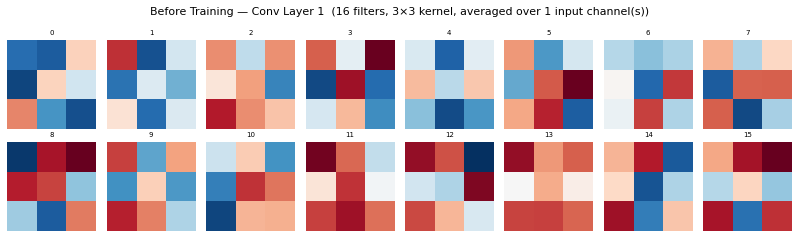

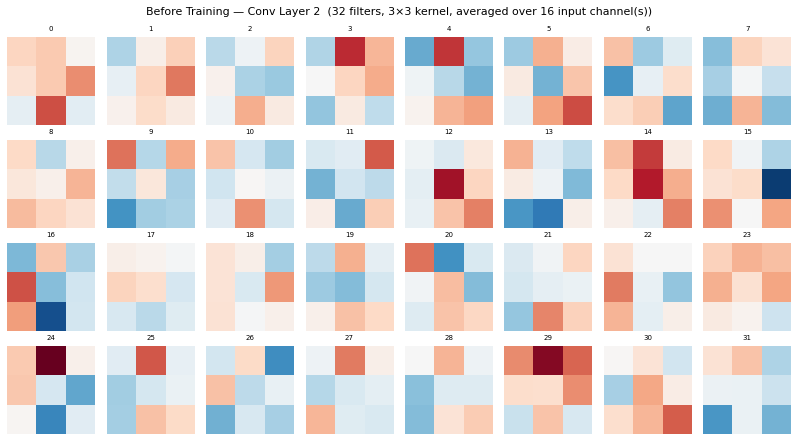

In [6]:
def plot_conv_filters(model, title_prefix=""):
    """
    Display the learned kernels of the first two Conv2d layers.
    For layer 1 (1 input channel): show each 3×3 kernel directly.
    For layer 2+ (multiple input channels): average over input channels first.
    """
    # Collect all Conv2d layers in order
    conv_layers = [(name, m) for name, m in model.named_modules()
                   if isinstance(m, nn.Conv2d)]

    for layer_idx, (name, layer) in enumerate(conv_layers[:2]):
        weights = layer.weight.detach().numpy()  # shape: (out_ch, in_ch, kH, kW)

        # Average across input channels for display purposes.
        # Layer 1: in_ch = 1, so this is a no-op.
        # Layer 2: in_ch = 16; averaging collapses the 16 channel directions into one.
        weights_display = weights.mean(axis=1)   # (out_ch, kH, kW)

        n_filters = weights_display.shape[0]
        n_cols = 8
        n_rows = (n_filters + n_cols - 1) // n_cols
        vmax = np.abs(weights_display).max()  # symmetric colour scale

        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(n_cols * 1.4, n_rows * 1.4 + 0.6))
        # Ensure axes is always a 2D array, even for a single row
        axes = np.array(axes).reshape(n_rows, n_cols)

        for idx in range(n_rows * n_cols):
            r, c = divmod(idx, n_cols)
            ax = axes[r, c]
            if idx < n_filters:
                ax.imshow(weights_display[idx], cmap='RdBu',
                          vmin=-vmax, vmax=vmax)
                ax.set_title(f"{idx}", fontsize=7)
            ax.axis('off')

        kH, kW = weights.shape[2], weights.shape[3]
        in_ch  = weights.shape[1]
        plt.suptitle(
            f"{title_prefix}Conv Layer {layer_idx + 1}  "
            f"({n_filters} filters, {kH}×{kW} kernel, "
            f"averaged over {in_ch} input channel(s))",
            fontsize=11
        )
        plt.tight_layout()
        plt.show()


plot_conv_filters(cnn, title_prefix="Before Training — ")

## 8. Training Functions

The same `evaluate` and `train` helpers as in the MLP notebook, with one addition: `train` now also measures the wall-clock time per epoch so we can compare training speed between architectures.

In [7]:
def evaluate(model, loader):
    """Return classification accuracy (%) on the given DataLoader."""
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            predicted = model(images).argmax(dim=1)
            correct  += (predicted == labels).sum().item()
            total    += labels.size(0)
    return 100.0 * correct / total


def train(model, train_loader, test_loader,
          n_epochs=10, lr=0.001, verbose=True):
    """
    Train `model` and return per-epoch training losses, test accuracies,
    and wall-clock times.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    losses     = []
    accuracies = []
    times      = []   # seconds per epoch

    for epoch in range(n_epochs):
        t0 = time.time()
        model.train()
        epoch_loss = 0.0

        for images, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        elapsed  = time.time() - t0
        avg_loss = epoch_loss / len(train_loader)
        acc      = evaluate(model, test_loader)

        losses.append(avg_loss)
        accuracies.append(acc)
        times.append(elapsed)

        if verbose:
            print(f"Epoch {epoch + 1:2d}/{n_epochs}  "
                  f"|  Loss: {avg_loss:.4f}  "
                  f"|  Test acc: {acc:.2f}%  "
                  f"|  {elapsed:.1f} s")

    return losses, accuracies, times

## 9. Train the CNN

Training a CNN on CPU typically takes 2–4 minutes for 10 epochs.

Epoch  1/10  |  Loss: 0.1634  |  Test acc: 98.20%  |  26.4 s
Epoch  2/10  |  Loss: 0.0512  |  Test acc: 98.69%  |  25.9 s
Epoch  3/10  |  Loss: 0.0354  |  Test acc: 98.92%  |  26.8 s
Epoch  4/10  |  Loss: 0.0266  |  Test acc: 98.80%  |  26.5 s
Epoch  5/10  |  Loss: 0.0213  |  Test acc: 98.91%  |  26.7 s
Epoch  6/10  |  Loss: 0.0158  |  Test acc: 98.95%  |  27.0 s
Epoch  7/10  |  Loss: 0.0136  |  Test acc: 99.07%  |  26.3 s
Epoch  8/10  |  Loss: 0.0108  |  Test acc: 98.89%  |  26.8 s
Epoch  9/10  |  Loss: 0.0103  |  Test acc: 98.98%  |  28.2 s
Epoch 10/10  |  Loss: 0.0094  |  Test acc: 98.87%  |  27.3 s


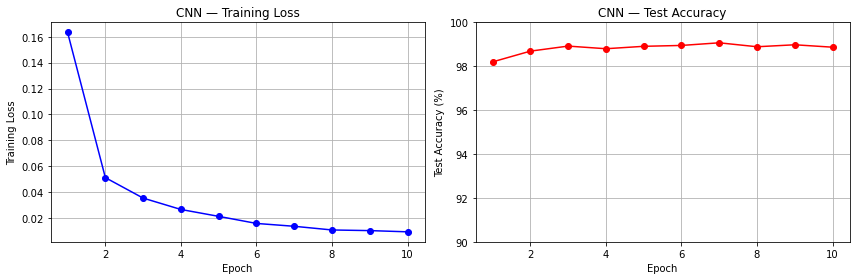


Final test accuracy : 98.87%
Mean time per epoch : 26.8 s


In [8]:
cnn = CNN(conv_channels=[16, 32], fc_sizes=[128])
cnn_losses, cnn_accs, cnn_times = train(cnn, train_loader, test_loader, n_epochs=10)

epochs = range(1, 11)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, cnn_losses, 'b-o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('CNN — Training Loss')
ax1.grid(True)

ax2.plot(epochs, cnn_accs, 'r-o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('CNN — Test Accuracy')
ax2.set_ylim([90, 100])
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal test accuracy : {cnn_accs[-1]:.2f}%")
print(f"Mean time per epoch : {np.mean(cnn_times):.1f} s")

## 10. Visualise Filters — After Training

The random noise should now have been replaced by structured patterns. Layer 1 filters typically learn simple local features: horizontal edges, vertical edges, diagonal strokes, blobs. These are the same kinds of features that appear in hand-crafted image processing kernels (Sobel, Laplacian, Gaussian), but the network discovered them purely from data.

Layer 2 filters combine the layer 1 features — they are harder to interpret directly, but averaging over input channels still reveals coarser spatial structure.

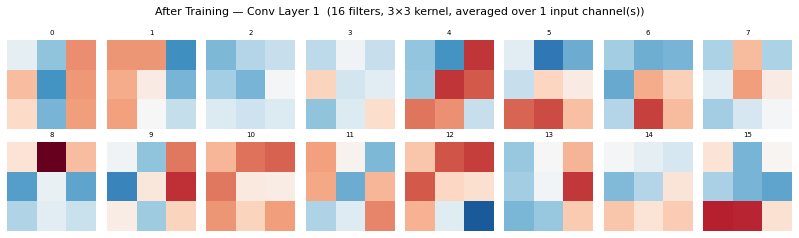

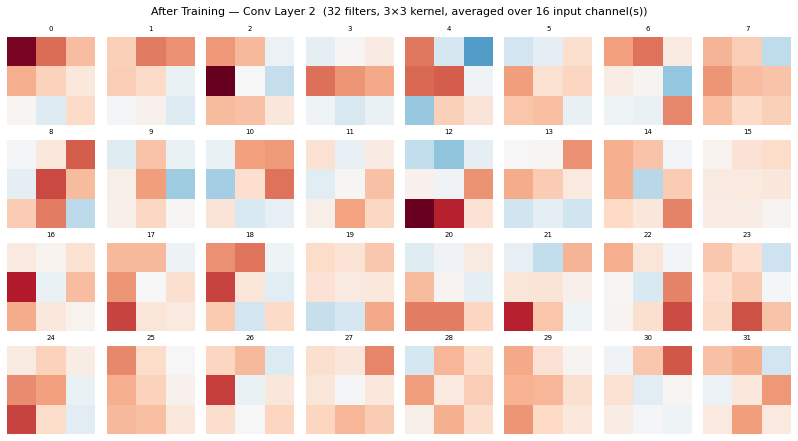

In [9]:
plot_conv_filters(cnn, title_prefix="After Training — ")

## 11. Feature Maps — What Does Each Layer "See"?

We can use PyTorch's **hook** mechanism to intercept the output of any layer during a forward pass — like tapping a wire in a circuit to read the signal without interrupting the flow. We attach the hooks to the `MaxPool2d` layers so we see the activations *after* convolution, ReLU, and pooling — exactly the tensor that gets passed to the next stage.

The **colour scale** is viridis: bright yellow means the filter responded strongly at that spatial location; dark purple means near-zero activation (the filter found nothing relevant there).

The feature maps below show, for a single test image, what each convolutional filter responds to:
- **After pool 1** (14×14): each map highlights simple local features in the original image — edges at specific orientations, blobs of ink, curves. Bright spots are where those features were detected.
- **After pool 2** (7×7): maps are spatially smaller and respond to combinations of layer-1 features — more abstract, higher-level patterns that span larger regions of the image.

This hierarchy — simple features in early layers, complex combinations in later layers — is the CNN's fundamental advantage. It mirrors how astronomers work: pixels → detected sources → morphological classification. Each level of processing abstracts away spatial detail and builds up semantic meaning.

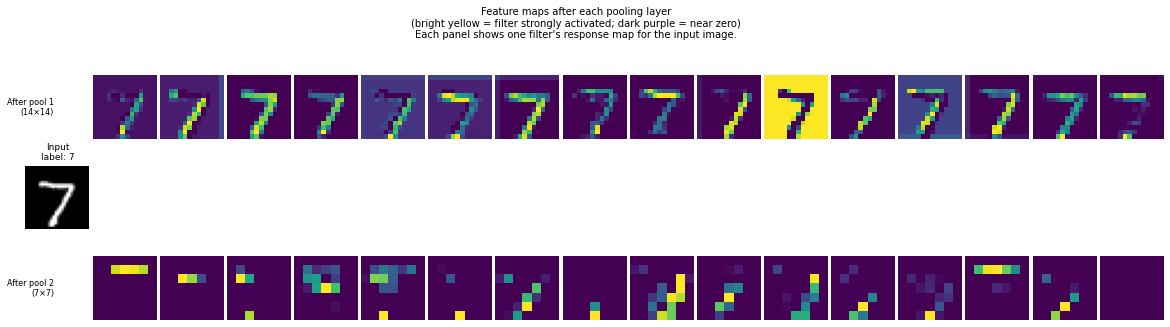

In [10]:
def plot_feature_maps(model, image_tensor, image_label):
    """
    Show the feature maps produced after each of the first two pooling layers.

    A 'hook' is a callback that PyTorch calls automatically each time a given
    layer processes data. We attach hooks to the MaxPool2d layers so we capture
    the activations *after* convolution, ReLU, and pooling — the actual input
    to the next layer.
    """
    activations = {}   # will be filled in by the hooks
    hooks       = []

    def make_hook(layer_name):
        def hook_fn(module, inp, output):
            activations[layer_name] = output.detach()
        return hook_fn

    # Attach hooks to MaxPool2d layers (not Conv2d) so we see post-ReLU,
    # post-pooled feature maps — the same tensors the next layer receives.
    pool_layers = [(name, m) for name, m in model.named_modules()
                   if isinstance(m, nn.MaxPool2d)]
    for name, layer in pool_layers[:2]:
        hooks.append(layer.register_forward_hook(make_hook(name)))

    # Run one image through the network; the hooks fire and populate `activations`
    model.eval()
    with torch.no_grad():
        model(image_tensor.unsqueeze(0))   # add batch dimension

    # Remove hooks so they do not affect future forward passes
    for h in hooks:
        h.remove()

    # --- Plotting ---
    fig = plt.figure(figsize=(17, 5))
    n_layer_cols = 16   # show up to 16 feature maps per row

    # GridSpec reserves one narrow column for the input image and 16 columns
    # for the feature maps, arranged in 2 rows (one per pooling layer).
    gs = gridspec.GridSpec(2, 1 + n_layer_cols,
                           figure=fig,
                           hspace=0.4, wspace=0.05,
                           left=0.05, right=0.98, top=0.88, bottom=0.02)

    # Left column: original image (spans both rows)
    ax_img = fig.add_subplot(gs[:, 0])
    ax_img.imshow(image_tensor.squeeze(), cmap='gray')
    ax_img.set_title(f'Input\nlabel: {image_label}', fontsize=9)
    ax_img.axis('off')

    for row_idx, (layer_name, fmaps) in enumerate(activations.items()):
        fmaps = fmaps[0]          # remove batch dim; shape: (n_ch, H, W)
        n_show = min(n_layer_cols, fmaps.shape[0])
        h, w = fmaps.shape[1], fmaps.shape[2]

        for col_idx in range(n_layer_cols):
            ax = fig.add_subplot(gs[row_idx, col_idx + 1])
            if col_idx < n_show:
                ax.imshow(fmaps[col_idx].numpy(), cmap='viridis')
            ax.axis('off')

            # Row label: ax.set_ylabel() is hidden by axis('off'), so we use
            # ax.text() with axes-relative coordinates instead.
            if col_idx == 0:
                ax.text(-0.6, 0.5, f'After pool {row_idx + 1}\n({h}×{w})',
                        transform=ax.transAxes,
                        fontsize=8, ha='right', va='center')

    plt.suptitle(
        'Feature maps after each pooling layer\n'
        '(bright yellow = filter strongly activated; dark purple = near zero)\n'
        'Each panel shows one filter\'s response map for the input image.',
        fontsize=10
    )
    plt.show()


# Pick a test image and show its feature maps
sample_idx = 0
img_tensor, true_label = test_dataset[sample_idx]
plot_feature_maps(cnn, img_tensor, true_label)

## 12. How Much Training Data Do We Need? (MLP vs CNN)

We train fresh MLP and CNN models on increasing fractions of the training set and compare their test accuracy.

The key concept here is **inductive bias** — the built-in assumptions an architecture makes about the structure of the data. The CNN assumes that useful features are *local* (a 3×3 patch is enough to detect a stroke) and *translation-invariant* (the same stroke looks the same wherever it appears). For handwritten digits, both assumptions are true.

Because the CNN's assumptions match the problem, it needs to discover less from the data — some structure is already "hard-coded" into the architecture. The MLP, by contrast, makes no spatial assumptions at all, so it must learn everything from scratch, which requires more examples.

We expect the CNN to outperform the MLP especially at small data fractions, where the MLP does not have enough examples to discover spatial structure on its own.

We use 5 epochs here (rather than 10) so the cell completes in a reasonable time. The relative ordering of the two curves is stable and the conclusion does not change with more epochs.

**This cell trains 14 models total (7 fractions × 2 architectures) and takes several minutes.**

   1%  (600 images)  |  MLP: 85.48%  |  CNN: 87.46%
   2%  (1,200 images)  |  MLP: 88.64%  |  CNN: 92.16%
   5%  (3,000 images)  |  MLP: 90.83%  |  CNN: 95.42%
  10%  (6,000 images)  |  MLP: 93.49%  |  CNN: 97.01%
  25%  (15,000 images)  |  MLP: 95.55%  |  CNN: 98.32%
  50%  (30,000 images)  |  MLP: 96.50%  |  CNN: 98.56%
 100%  (60,000 images)  |  MLP: 97.55%  |  CNN: 98.83%


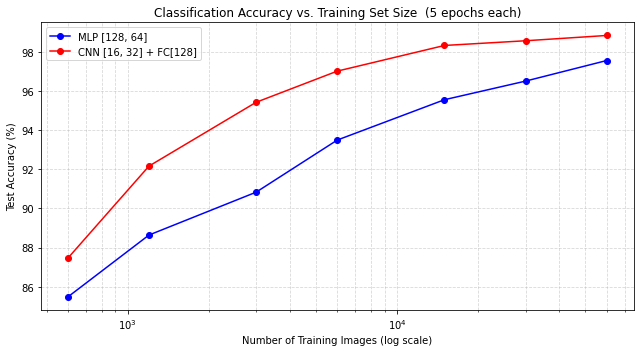

In [11]:
fractions     = [0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 1.0]
mlp_frac_accs = []
cnn_frac_accs = []

for frac in fractions:
    n_samples = int(len(train_dataset) * frac)
    indices   = random.sample(range(len(train_dataset)), n_samples)
    subset    = Subset(train_dataset, indices)
    loader    = DataLoader(subset, batch_size=64, shuffle=True)

    # MLP — 5 epochs is enough to see the accuracy level for each data fraction
    m_mlp = MLP(hidden_sizes=[128, 64])
    train(m_mlp, loader, test_loader, n_epochs=5, verbose=False)
    mlp_acc = evaluate(m_mlp, test_loader)
    mlp_frac_accs.append(mlp_acc)

    # CNN
    m_cnn = CNN(conv_channels=[16, 32], fc_sizes=[128])
    train(m_cnn, loader, test_loader, n_epochs=5, verbose=False)
    cnn_acc = evaluate(m_cnn, test_loader)
    cnn_frac_accs.append(cnn_acc)

    print(f"{frac:5.0%}  ({n_samples:,} images)  |  MLP: {mlp_acc:.2f}%  |  CNN: {cnn_acc:.2f}%")

# Plot
n_train_images = [int(f * len(train_dataset)) for f in fractions]

plt.figure(figsize=(9, 5))
plt.plot(n_train_images, mlp_frac_accs, 'b-o', label='MLP [128, 64]')
plt.plot(n_train_images, cnn_frac_accs, 'r-o', label='CNN [16, 32] + FC[128]')
plt.xscale('log')
plt.xlabel('Number of Training Images (log scale)')
plt.ylabel('Test Accuracy (%)')
plt.title('Classification Accuracy vs. Training Set Size  (5 epochs each)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 13. How Do CNN Depth and Width Affect Performance?

Just as we varied MLP depth and width, here we vary the CNN's convolutional stack. We use 5 epochs so the cell completes quickly; the relative ordering of the architectures is stable.

| Architecture | Conv layers | Total params | 5-epoch accuracy |
|---|---|---|---|
| Shallow & Narrow | [16] | ~403 k | 98.41% |
| Shallow & Wide | [64] | ~1608 k | 98.51% |
| Default (2 layers) | [16, 32] | ~207 k | 98.95% |
| Deep (3 layers) | [16, 32, 64] | ~98 k | 99.00% |

**A counter-intuitive result:** the Deep architecture has the *fewest* parameters yet the *best* accuracy. The Shallow & Wide has the *most* parameters yet the *worst* accuracy of the four.

Why? Each MaxPool2d halves both spatial dimensions, so the number of pooling layers controls how large the feature maps are when they reach the fully-connected head — and that FC head dominates the total parameter count:

| Architecture | Pools | Spatial size entering FC | FC input size | Approximate total |
|---|---|---|---|---|
| Shallow [16] | 1× | 14×14 | 16 × 14 × 14 = **3,136** | ~403 k |
| Shallow [64] | 1× | 14×14 | 64 × 14 × 14 = **12,544** | ~1608 k |
| Default [16,32] | 2× | 7×7 | 32 × 7 × 7 = **1,568** | ~207 k |
| Deep [16,32,64] | 3× | 3×3 | 64 × 3 × 3 = **576** | ~98 k |

Three rounds of pooling compress 28×28 down to 3×3, shrinking the FC head by a factor of ~22 compared with the one-pool shallow version. The deep CNN is both smaller *and* more accurate because its extra pooling layers force it to build more abstract, translation-invariant representations before the classification step.

This is the same lesson as the data-fraction experiment: the right *structure* matters more than raw parameter count.


Training CNN: Shallow & Narrow  [16]  (402,986 parameters)
  Final test accuracy: 98.41%

Training CNN: Shallow & Wide  [64]  (1,607,690 parameters)
  Final test accuracy: 98.51%

Training CNN: Default  [16, 32]  (206,922 parameters)
  Final test accuracy: 98.95%

Training CNN: Deep  [16, 32, 64]  (98,442 parameters)
  Final test accuracy: 99.00%


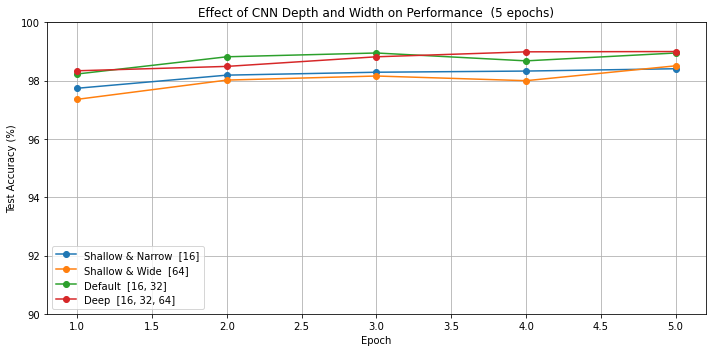

In [12]:
cnn_architectures = {
    "Shallow & Narrow  [16]": ([16], [128]),
    "Shallow & Wide  [64]": ([64], [128]),
    "Default  [16, 32]": ([16, 32], [128]),
    "Deep  [16, 32, 64]": ([16, 32, 64], [128]),
}

cnn_arch_results = {}

for name, (conv_ch, fc_sz) in cnn_architectures.items():
    m = CNN(conv_channels=conv_ch, fc_sizes=fc_sz)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"\nTraining CNN: {name}  ({n_params:,} parameters)")
    _, accs, _ = train(m, train_loader, test_loader, n_epochs=5, verbose=False)
    cnn_arch_results[name] = accs
    print(f"  Final test accuracy: {accs[-1]:.2f}%")

plt.figure(figsize=(10, 5))
for name, accs in cnn_arch_results.items():
    plt.plot(range(1, len(accs) + 1), accs, '-o', label=name)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Effect of CNN Depth and Width on Performance  (5 epochs)')
plt.legend()
plt.grid(True)
plt.ylim([90, 100])
plt.tight_layout()
plt.show()

## 14. Head-to-Head: MLP vs CNN

We now train both architectures from scratch under **identical conditions** — same data, same optimiser, same number of epochs — and compare:

1. Learning curves (accuracy vs. epoch)
2. Final test accuracy
3. Training speed (seconds per epoch)
4. Accuracy-per-parameter efficiency

In [13]:
# --- Train both architectures ---
print("Training MLP [128, 64]...")
mlp_h2h = MLP(hidden_sizes=[128, 64])
mlp_losses, mlp_accs, mlp_times = train(mlp_h2h, train_loader, test_loader, n_epochs=10)

print("\nTraining CNN [16, 32] + FC[128]...")
cnn_h2h = CNN(conv_channels=[16, 32], fc_sizes=[128])
cnn_losses, cnn_accs, cnn_times = train(cnn_h2h, train_loader, test_loader, n_epochs=10)

Training MLP [128, 64]...
Epoch  1/10  |  Loss: 0.2710  |  Test acc: 95.68%  |  9.3 s
Epoch  2/10  |  Loss: 0.1144  |  Test acc: 96.68%  |  9.3 s
Epoch  3/10  |  Loss: 0.0793  |  Test acc: 96.94%  |  9.3 s
Epoch  4/10  |  Loss: 0.0605  |  Test acc: 97.43%  |  9.3 s
Epoch  5/10  |  Loss: 0.0490  |  Test acc: 97.65%  |  9.9 s
Epoch  6/10  |  Loss: 0.0393  |  Test acc: 97.95%  |  9.6 s
Epoch  7/10  |  Loss: 0.0341  |  Test acc: 97.81%  |  9.7 s
Epoch  8/10  |  Loss: 0.0300  |  Test acc: 97.87%  |  9.4 s
Epoch  9/10  |  Loss: 0.0247  |  Test acc: 97.87%  |  9.4 s
Epoch 10/10  |  Loss: 0.0237  |  Test acc: 97.86%  |  9.3 s

Training CNN [16, 32] + FC[128]...
Epoch  1/10  |  Loss: 0.1660  |  Test acc: 98.26%  |  27.2 s
Epoch  2/10  |  Loss: 0.0492  |  Test acc: 98.72%  |  27.2 s
Epoch  3/10  |  Loss: 0.0342  |  Test acc: 98.73%  |  28.8 s
Epoch  4/10  |  Loss: 0.0271  |  Test acc: 98.92%  |  28.5 s
Epoch  5/10  |  Loss: 0.0208  |  Test acc: 98.95%  |  27.6 s
Epoch  6/10  |  Loss: 0.0156  |  

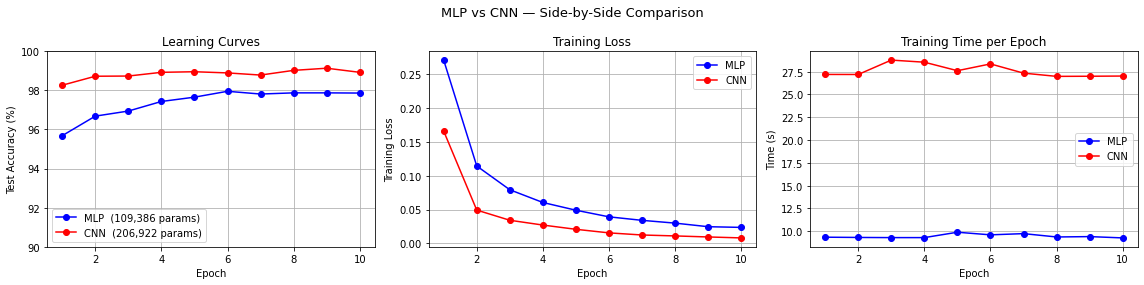


Metric                                  MLP          CNN
------------------------------------------------------------
Parameters                          109,386      206,922
Final test accuracy (%)               97.86        98.92
Mean time/epoch (s)                     9.5         27.6
Accuracy gain (CNN - MLP)             +1.06


In [14]:
epochs = range(1, 11)
n_mlp  = sum(p.numel() for p in mlp_h2h.parameters())
n_cnn  = sum(p.numel() for p in cnn_h2h.parameters())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Panel 1: Learning curves ---
axes[0].plot(epochs, mlp_accs, 'b-o', label=f'MLP  ({n_mlp:,} params)')
axes[0].plot(epochs, cnn_accs, 'r-o', label=f'CNN  ({n_cnn:,} params)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Learning Curves')
axes[0].legend()
axes[0].grid(True)
axes[0].set_ylim([90, 100])

# --- Panel 2: Training loss ---
axes[1].plot(epochs, mlp_losses, 'b-o', label='MLP')
axes[1].plot(epochs, cnn_losses, 'r-o', label='CNN')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Training Loss')
axes[1].set_title('Training Loss')
axes[1].legend()
axes[1].grid(True)

# --- Panel 3: Time per epoch ---
axes[2].plot(epochs, mlp_times, 'b-o', label='MLP')
axes[2].plot(epochs, cnn_times, 'r-o', label='CNN')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Time (s)')
axes[2].set_title('Training Time per Epoch')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('MLP vs CNN — Side-by-Side Comparison', fontsize=13)
plt.tight_layout()
plt.show()

# --- Summary table ---
print("\n" + "="*60)
print(f"{'Metric':<30} {'MLP':>12} {'CNN':>12}")
print("-"*60)
print(f"{'Parameters':<30} {n_mlp:>12,} {n_cnn:>12,}")
print(f"{'Final test accuracy (%)':<30} {mlp_accs[-1]:>12.2f} {cnn_accs[-1]:>12.2f}")
print(f"{'Mean time/epoch (s)':<30} {np.mean(mlp_times):>12.1f} {np.mean(cnn_times):>12.1f}")
improvement = cnn_accs[-1] - mlp_accs[-1]
print(f"{'Accuracy gain (CNN - MLP)':<30} {improvement:>+12.2f}")
print("="*60)

## 15. Classify a Single Test Image — Both Models

Set `image_index` to any number from 0 to 9,999 to pick a test image. The confidence bar charts for both models are shown side by side — this makes it easy to spot cases where the CNN is more confident or where one model fails and the other succeeds.

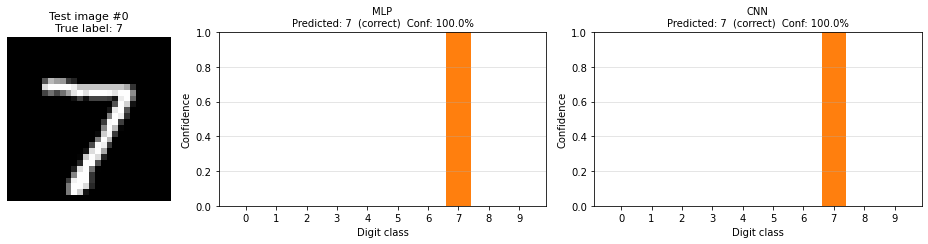

In [15]:
# -------------------------------------------------------
# Change this to select a different test image (0–9999)
image_index = 0
# -------------------------------------------------------

img_tensor, true_label = test_dataset[image_index]

def get_probs(model, img_tensor):
    """Return softmax probabilities for one image."""
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0))
    return torch.softmax(logits, dim=1).squeeze().numpy()


mlp_probs  = get_probs(mlp_h2h, img_tensor)
cnn_probs  = get_probs(cnn_h2h, img_tensor)
mlp_pred   = int(mlp_probs.argmax())
cnn_pred   = int(cnn_probs.argmax())

fig, (ax_img, ax_mlp, ax_cnn) = plt.subplots(1, 3, figsize=(13, 3.5),
                                              gridspec_kw={'width_ratios': [1, 2, 2]})

# Input image
ax_img.imshow(img_tensor.squeeze(), cmap='gray')
ax_img.set_title(f'Test image #{image_index}\nTrue label: {true_label}', fontsize=11)
ax_img.axis('off')

# Helper to draw a confidence bar chart
def plot_confidence(ax, probs, pred, label, title):
    colours = ['tab:blue'] * 10
    colours[pred] = 'tab:orange'
    ax.bar(range(10), probs, color=colours)
    ax.set_xticks(range(10))
    ax.set_xlabel('Digit class')
    ax.set_ylabel('Confidence')
    ax.set_ylim(0, 1)
    outcome = 'correct' if pred == label else 'WRONG'
    ax.set_title(f'{title}\nPredicted: {pred}  ({outcome})  Conf: {probs[pred]:.1%}',
                 fontsize=10)
    ax.grid(axis='y', alpha=0.4)


plot_confidence(ax_mlp, mlp_probs, mlp_pred, true_label, 'MLP')
plot_confidence(ax_cnn, cnn_probs, cnn_pred, true_label, 'CNN')

plt.tight_layout()
plt.show()

## Summary

In this notebook we:

1. **Motivated CNNs** from first principles — convolution is the natural operation for data with spatial structure, just as cross-correlation and matched filtering are natural in signal processing and radio astronomy.
2. **Built a flexible CNN** and visualised its architecture as both an ASCII flow diagram and a matplotlib figure.
3. **Visualised conv filters before and after training** — random noise becomes structured edge and texture detectors, discovered entirely from data.
4. **Inspected feature maps** to see the hierarchy the CNN builds: local edges in layer 1, abstract combinations in layer 2.
5. **Measured data efficiency** — the CNN's built-in translation invariance means it learns more from each labelled example, especially when training data is scarce.
6. **Compared CNN architectures** — deeper CNNs do not automatically have more parameters (more pooling → smaller feature maps → smaller FC head).
7. **Did a head-to-head comparison** — the CNN achieves higher accuracy than the MLP with a similar parameter budget, purely because its architecture encodes the right inductive bias for image data.

### The key lesson

Performance comes not just from having more parameters, but from building in the right **symmetries and structure** for the problem at hand. A model that knows images are translation-invariant and locally structured will generalise better from the same amount of data. This is a completely general principle: in physics, models that respect the symmetries of the system are always more predictive than ones that do not.

### Things to try
- Change `image_index` in Section 15 to find examples where the MLP fails but the CNN succeeds — what do those images look like?
- Try `conv_channels=[32, 64, 128]` — does more depth keep helping?
- Try reducing `fc_sizes=[]` (no hidden FC layer, just a linear classifier on top of the conv features) — how much does the FC head matter?
- Try `kernel_size=5` instead of 3 — larger receptive field per layer. Does it help?